<a href="https://colab.research.google.com/github/shankar-011/GenAI-Internship/blob/master/day4(assignment).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os
import cv2

zip_path = "/content/archive (1).zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 1100


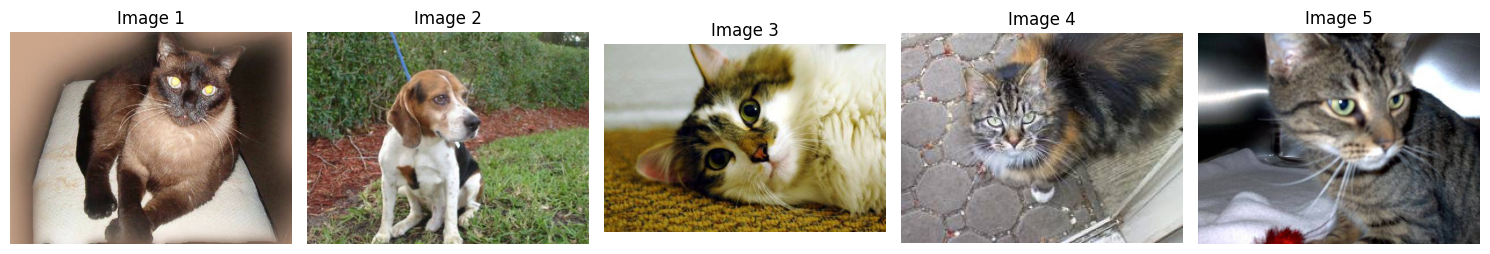

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

for i in range(5):
    img_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"Image {i+1}")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

image_info = []

for i, img in enumerate(images):
    h, w, c = img.shape

    image_info.append([
        f"Image_{i+1}",
        h,
        w,
        c
    ])

df = pd.DataFrame(
    image_info,
    columns=["Image", "Height", "Width", "Channels"]
)

df.head()

,Image,Height,Width,Channels
0,Image_1,375,499,3
1,Image_2,375,499,3
2,Image_3,332,499,3
3,Image_4,181,243,3
4,Image_5,374,500,3


In [ ]:
df.describe()

,Height,Width,Channels
count,1100.000000,1100.000000,1100.0
mean,357.082727,400.613636,3.0
std,99.411203,110.811773,0.0
min,59.000000,74.000000,3.0
25%,299.000000,320.000000,3.0
50%,374.000000,434.000000,3.0
75%,414.000000,499.000000,3.0
max,500.000000,500.000000,3.0


In [ ]:
resized_images = []

for img in images:
    resized = cv2.resize(img, (224,224))
    resized_images.append(resized)

print("Original Shape:", images[0].shape)
print("Resized Shape:", resized_images[0].shape)

Original Shape: (375, 499, 3)
Resized Shape: (224, 224, 3)


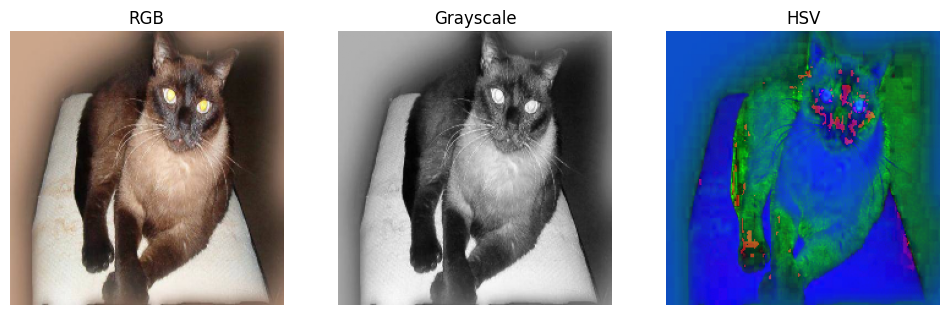

In [ ]:
img = resized_images[0]

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(rgb)
plt.title("RGB")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(hsv)
plt.title("HSV")
plt.axis("off")

plt.show()

In [ ]:
normalized_images = []

for img in resized_images:
    normalized_images.append(img / 255.0)

print("Minimum:", normalized_images[0].min())
print("Maximum:", normalized_images[0].max())

Minimum: 0.0
Maximum: 1.0


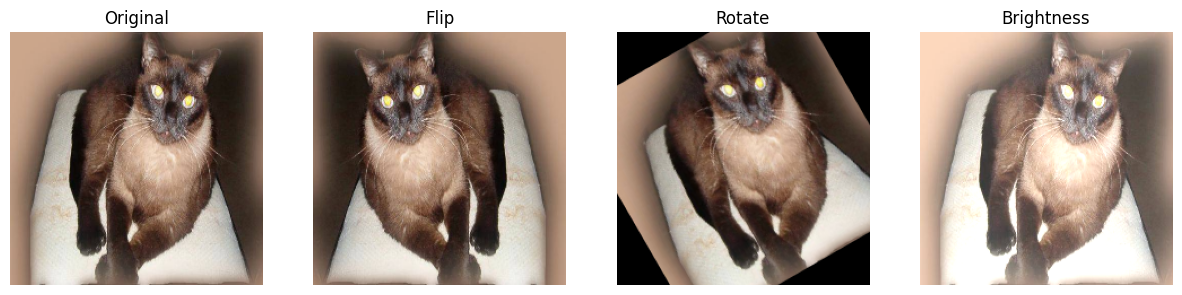

In [ ]:
img = resized_images[0]

flip = cv2.flip(img, 1)

rows, cols = img.shape[:2]

M = cv2.getRotationMatrix2D(
    (cols/2, rows/2),
    30,
    1
)

rotated = cv2.warpAffine(
    img,
    M,
    (cols, rows)
)

bright = cv2.convertScaleAbs(
    img,
    alpha=1,
    beta=50
)

plt.figure(figsize=(15,4))

plt.subplot(1,4,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(cv2.cvtColor(flip, cv2.COLOR_BGR2RGB))
plt.title("Flip")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
plt.title("Rotate")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(cv2.cvtColor(bright, cv2.COLOR_BGR2RGB))
plt.title("Brightness")
plt.axis("off")

plt.show()

In [ ]:
def preprocess_image(img):

    img = cv2.resize(img, (224,224))

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    normalized = img / 255.0

    blurred = cv2.GaussianBlur(
        img,
        (5,5),
        0
    )

    edges = cv2.Canny(
        gray,
        100,
        200
    )

    return {
        "gray": gray,
        "normalized": normalized,
        "blurred": blurred,
        "edges": edges
    }

result = preprocess_image(images[0])

print(result.keys())

dict_keys(['gray', 'normalized', 'blurred', 'edges'])
